# Extended Profiler: Memoria en 10 Ítems

Auditoría de consumo de memoria/tiempo para modelos difusivos usando CSV de profiler.

- Fuente primaria: `profiler/profiler_runs_summary_core.csv`
- Fallback: `profiler/profiler_runs_summary.csv`
- Comparativa principal: `AMP` vs `FP32`
- GPU de referencia: RTX A5000 (`23.68 GB`)

Notas rápidas:
- `ms` = tiempo (milisegundos), no memoria.
- `trace` = agregados sobre eventos de `traceEvents` del profiler.
- Memoria por fase usa eventos `[memory]`: `Total Allocated` y `Bytes`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "grid.alpha": 0.20,
})

A5000_GB = 23.68
A5000_GUIDES = [
    (0.80 * A5000_GB, "80%"),
    (0.85 * A5000_GB, "85%"),
    (0.90 * A5000_GB, "90%"),
    (1.00 * A5000_GB, "100%"),
]
PALETTE = {False: "#1f77b4", True: "#ff7f0e"}
AMP_LABELS = {True: "AMP", False: "FP32"}
PHASE_COLORS = {
    "train_forward": "#1f77b4",
    "train_backward": "#ff7f0e",
    "train_step": "#2ca02c",
}


def find_project_root():
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "profiler").exists() and (p / "src").exists():
            return p
    raise RuntimeError("No se pudo resolver project root (esperado: profiler/ y src/).")


def normalize_use_amp(s):
    return s.astype(str).str.strip().str.lower().map({"true": True, "false": False})


def fit_line(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan, np.nan
    slope, intercept = np.polyfit(x[m], y[m], 1)
    return float(slope), float(intercept)


def add_a5000_guides(ax):
    for y, tag in A5000_GUIDES:
        ax.axhline(y=y, linestyle="--", linewidth=1.0, color="#6b7280", alpha=0.7)
        ax.text(0.99, y, f" {tag} ({y:.2f} GB)", transform=ax.get_yaxis_transform(),
                ha="right", va="bottom", fontsize=8, color="#4b5563")


def relabel_amp_legend(ax):
    h, l = ax.get_legend_handles_labels()
    if not h:
        return
    mapped = []
    for item in l:
        if item in ("True", "False"):
            mapped.append(AMP_LABELS[item == "True"])
        else:
            mapped.append(item)
    ax.legend(h, mapped, loc="best")


def mini_conclusion(title, lines):
    print(f"\n[{title}]")
    for ln in lines:
        print(f"- {ln}")


In [2]:
PROJECT_ROOT = find_project_root()
PROFILER_DIR = PROJECT_ROOT / "profiler"
core_csv = PROFILER_DIR / "profiler_runs_summary_core.csv"
full_csv = PROFILER_DIR / "profiler_runs_summary.csv"

if core_csv.exists():
    csv_path = core_csv
elif full_csv.exists():
    csv_path = full_csv
else:
    raise FileNotFoundError("No se encontró profiler_runs_summary_core.csv ni profiler_runs_summary.csv")

df = pd.read_csv(csv_path)
print(f"CSV cargado: {csv_path}")
print(f"rows={len(df)} cols={len(df.columns)}")

CSV cargado: /home/gkulemeyer/Documents/Repos/RNADiffusion/profiler/profiler_runs_summary_core.csv
rows=42 cols=42


In [3]:
num_cols = [
    "timesteps", "batch_size", "oom_events",
    "max_alloc_gb_trace", "max_reserved_gb_trace",
    "train_batch_ms", "train_forward_ms", "train_backward_ms", "train_step_ms",
    "eval_no_f1_ms", "eval_with_f1_ms",
    "cpu_op_ms_trace", "gpu_total_ms_trace",
    "train_forward_alloc_delta_avg_mb_gpu", "train_forward_alloc_delta_peak_mb_gpu",
    "train_backward_alloc_delta_avg_mb_gpu", "train_backward_alloc_delta_peak_mb_gpu",
    "train_step_alloc_delta_avg_mb_gpu", "train_step_alloc_delta_peak_mb_gpu",
    "train_forward_alloc_delta_avg_mb_cpu", "train_forward_alloc_delta_peak_mb_cpu",
    "train_backward_alloc_delta_avg_mb_cpu", "train_backward_alloc_delta_peak_mb_cpu",
    "train_step_alloc_delta_avg_mb_cpu", "train_step_alloc_delta_peak_mb_cpu",
    "train_forward_alloc_traffic_mb_gpu", "train_forward_free_traffic_mb_gpu",
    "train_backward_alloc_traffic_mb_gpu", "train_backward_free_traffic_mb_gpu",
    "train_step_alloc_traffic_mb_gpu", "train_step_free_traffic_mb_gpu",
    "train_forward_alloc_traffic_mb_cpu", "train_forward_free_traffic_mb_cpu",
    "train_backward_alloc_traffic_mb_cpu", "train_backward_free_traffic_mb_cpu",
    "train_step_alloc_traffic_mb_cpu", "train_step_free_traffic_mb_cpu",
]
for c in num_cols:
    if c not in df.columns:
        df[c] = np.nan
    df[c] = pd.to_numeric(df[c], errors="coerce")

if "use_amp" in df.columns:
    df["use_amp"] = normalize_use_amp(df["use_amp"])
else:
    df["use_amp"] = np.nan

if "status" not in df.columns:
    df["status"] = "unknown"
if "run_name" not in df.columns:
    df["run_name"] = [f"run_{i}" for i in range(len(df))]

for src, dst in [
    ("train_batch_ms", "train_batch_s"),
    ("train_forward_ms", "train_forward_s"),
    ("train_backward_ms", "train_backward_s"),
    ("train_step_ms", "train_step_s"),
    ("eval_no_f1_ms", "eval_no_f1_s"),
    ("eval_with_f1_ms", "eval_with_f1_s"),
    ("cpu_op_ms_trace", "cpu_op_s_trace"),
    ("gpu_total_ms_trace", "gpu_total_s_trace"),
]:
    df[dst] = df[src] / 1000.0

df["is_oom"] = df["oom_events"].fillna(0) > 0
df["is_ok"] = df["status"].astype(str).str.lower().eq("ok")
df["cpu_gpu_ratio"] = df["cpu_op_ms_trace"] / df["gpu_total_ms_trace"]
df["cpu_gpu_ratio"] = df["cpu_gpu_ratio"].replace([np.inf, -np.inf], np.nan)

df["headroom_gb"] = A5000_GB - df["max_alloc_gb_trace"]
df["headroom_pct"] = 100.0 * df["headroom_gb"] / A5000_GB

df["frag_gap_gb"] = df["max_reserved_gb_trace"] - df["max_alloc_gb_trace"]
df["frag_ratio"] = df["frag_gap_gb"] / df["max_reserved_gb_trace"]
df["frag_ratio"] = df["frag_ratio"].replace([np.inf, -np.inf], np.nan)

df = df.sort_values(["timesteps", "use_amp"], na_position="last").reset_index(drop=True)
display(df[["run_name", "status", "timesteps", "batch_size", "use_amp", "oom_events"]].head(12))

,run_name,status,timesteps,batch_size,use_amp,oom_events
0,sim90_bs4_pb4_5ts_fp32,ok,5,4,False,0.0
1,sim90_bs4_pb4_5ts_amp,ok,5,4,True,0.0
2,sim90_bs4_pb4_10ts,unknown,10,4,False,0.0
3,sim90_bs4_pb4_10ts_fp32,ok,10,4,False,0.0
4,sim90_bs4_pb4_10ts_amp,ok,10,4,True,0.0
5,sim90_bs4_pb4_15ts_fp32,ok,15,4,False,0.0
6,sim90_bs4_pb4_15ts_amp,ok,15,4,True,0.0
7,sim90_bs4_pb4_25ts,unknown,25,4,False,0.0
8,sim90_bs4_pb4_25ts_fp32,ok,25,4,False,0.0
9,sim90_bs4_pb4_25ts_amp,ok,25,4,True,0.0


## Item 1: Presupuesto fijo (heurístico)
Se estima `max_alloc_gb_trace ~ slope * timesteps + intercept` por modo.
- `intercept` se usa como memoria base fija aproximada.
- Split heurístico (Adam FP32): params 25%, grads 25%, optimizer states 50%.

,mode,slope_gb_per_ts,intercept_gb,fixed_base_gb,params_gb_est,grads_gb_est,optim_states_gb_est,n_points
0,AMP,0.325606,0.483840,0.483840,0.120960,0.120960,0.241920,17
1,FP32,0.357125,0.347032,0.347032,0.086758,0.086758,0.173516,17


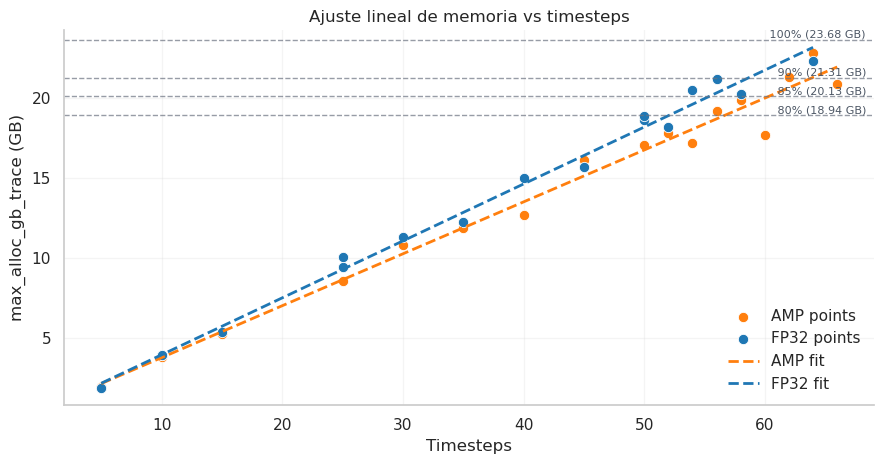


[Item 1]
- `intercept` es una aproximación de memoria base fija; no reemplaza un perfil estructural de params reales.
- El split params/grads/optimizer (25/25/50) es heurístico para orientación inicial.
- Memoria base estimada (mediana): 0.42 GB


In [4]:
fit_rows = []
fit_plot = []
base_df = df[(~df["is_oom"]) & df["timesteps"].notna() & df["max_alloc_gb_trace"].notna()]

for amp in [True, False]:
    sub = base_df[base_df["use_amp"] == amp].copy()
    slope, intercept = fit_line(sub["timesteps"], sub["max_alloc_gb_trace"])
    fixed_gb = max(intercept, 0.0) if np.isfinite(intercept) else np.nan

    fit_rows.append({
        "mode": AMP_LABELS[amp],
        "slope_gb_per_ts": slope,
        "intercept_gb": intercept,
        "fixed_base_gb": fixed_gb,
        "params_gb_est": fixed_gb * 0.25 if np.isfinite(fixed_gb) else np.nan,
        "grads_gb_est": fixed_gb * 0.25 if np.isfinite(fixed_gb) else np.nan,
        "optim_states_gb_est": fixed_gb * 0.50 if np.isfinite(fixed_gb) else np.nan,
        "n_points": len(sub),
    })

    if len(sub) >= 2 and np.isfinite(slope) and np.isfinite(intercept):
        xfit = np.linspace(sub["timesteps"].min(), sub["timesteps"].max(), 100)
        yfit = slope * xfit + intercept
        fit_plot.append((amp, sub, xfit, yfit))

fit_df = pd.DataFrame(fit_rows)
display(fit_df)

fig, ax = plt.subplots(figsize=(9, 4.8))
for amp in [True, False]:
    sub = base_df[base_df["use_amp"] == amp]
    if len(sub):
        sns.scatterplot(data=sub, x="timesteps", y="max_alloc_gb_trace", color=PALETTE[amp], s=55, ax=ax, label=f"{AMP_LABELS[amp]} points")
for amp, sub, xfit, yfit in fit_plot:
    ax.plot(xfit, yfit, color=PALETTE[amp], linewidth=2.0, linestyle="--", label=f"{AMP_LABELS[amp]} fit")

add_a5000_guides(ax)
ax.set_title("Ajuste lineal de memoria vs timesteps")
ax.set_xlabel("Timesteps")
ax.set_ylabel("max_alloc_gb_trace (GB)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

lines = [
    "`intercept` es una aproximación de memoria base fija; no reemplaza un perfil estructural de params reales.",
    "El split params/grads/optimizer (25/25/50) es heurístico para orientación inicial.",
]
if fit_df["fixed_base_gb"].notna().any():
    lines.append(f"Memoria base estimada (mediana): {fit_df['fixed_base_gb'].median():.2f} GB")
mini_conclusion("Item 1", lines)

## Item 2: Escalamiento empírico
Curvas y pendientes de memoria/tiempo vs `timesteps`, con proyección a `TS_TARGET`.

,mode,mem_slope_gb_per_ts,mem_pred_gb_at_target,train_slope_s_per_ts,train_pred_s_at_target
0,AMP,0.325606,33.044487,0.025785,2.558156
1,FP32,0.357125,36.059491,0.019997,2.042567


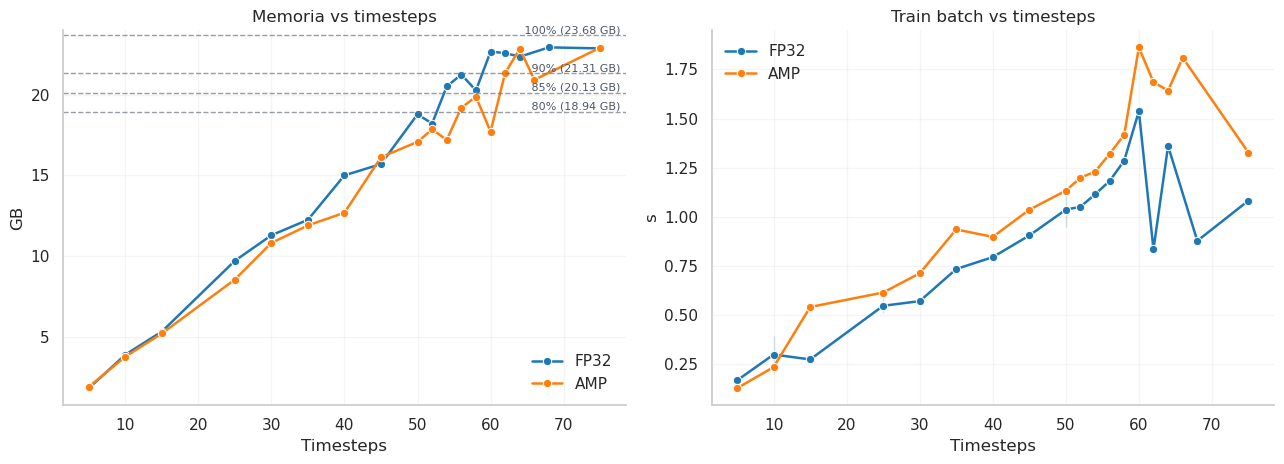


[Item 2]
- Proyección hecha para ts=100 con ajuste lineal simple (no extrapolación robusta).
- Predicción mediana memoria @ts=100: 34.55 GB
- No hay variación suficiente en batch_size para estimar pendiente confiable vs batch.


In [5]:
TS_TARGET = 100
rows = []
for amp in [True, False]:
    sub = base_df[base_df["use_amp"] == amp]
    mem_m, mem_b = fit_line(sub["timesteps"], sub["max_alloc_gb_trace"])
    tsub = df[(~df["is_oom"]) & (df["use_amp"] == amp) & df["timesteps"].notna() & df["train_batch_s"].notna()]
    t_m, t_b = fit_line(tsub["timesteps"], tsub["train_batch_s"])
    rows.append({
        "mode": AMP_LABELS[amp],
        "mem_slope_gb_per_ts": mem_m,
        "mem_pred_gb_at_target": mem_m * TS_TARGET + mem_b if np.isfinite(mem_m) and np.isfinite(mem_b) else np.nan,
        "train_slope_s_per_ts": t_m,
        "train_pred_s_at_target": t_m * TS_TARGET + t_b if np.isfinite(t_m) and np.isfinite(t_b) else np.nan,
    })

scale_df = pd.DataFrame(rows)
display(scale_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
mem_sub = df.dropna(subset=["timesteps", "max_alloc_gb_trace", "use_amp"])
sns.lineplot(data=mem_sub, x="timesteps", y="max_alloc_gb_trace", hue="use_amp", palette=PALETTE, marker="o", linewidth=1.8, ax=axes[0])
add_a5000_guides(axes[0])
relabel_amp_legend(axes[0])
axes[0].set_title("Memoria vs timesteps")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("GB")

tr_sub = df.dropna(subset=["timesteps", "train_batch_s", "use_amp"])
sns.lineplot(data=tr_sub, x="timesteps", y="train_batch_s", hue="use_amp", palette=PALETTE, marker="o", linewidth=1.8, ax=axes[1])
relabel_amp_legend(axes[1])
axes[1].set_title("Train batch vs timesteps")
axes[1].set_xlabel("Timesteps")
axes[1].set_ylabel("s")
plt.tight_layout()
plt.show()

lines = [f"Proyección hecha para ts={TS_TARGET} con ajuste lineal simple (no extrapolación robusta)."]
if scale_df["mem_pred_gb_at_target"].notna().any():
    lines.append(
        f"Predicción mediana memoria @ts={TS_TARGET}: {scale_df['mem_pred_gb_at_target'].median():.2f} GB"
    )
if df["batch_size"].nunique(dropna=True) <= 1:
    lines.append("No hay variación suficiente en batch_size para estimar pendiente confiable vs batch.")
mini_conclusion("Item 2", lines)

## Item 3: Fase real (`delta` + `traffic`) por dispositivo
`delta_live` muestra subida neta de memoria activa en fase.
`alloc/free traffic` muestra actividad del allocator dentro de fase.

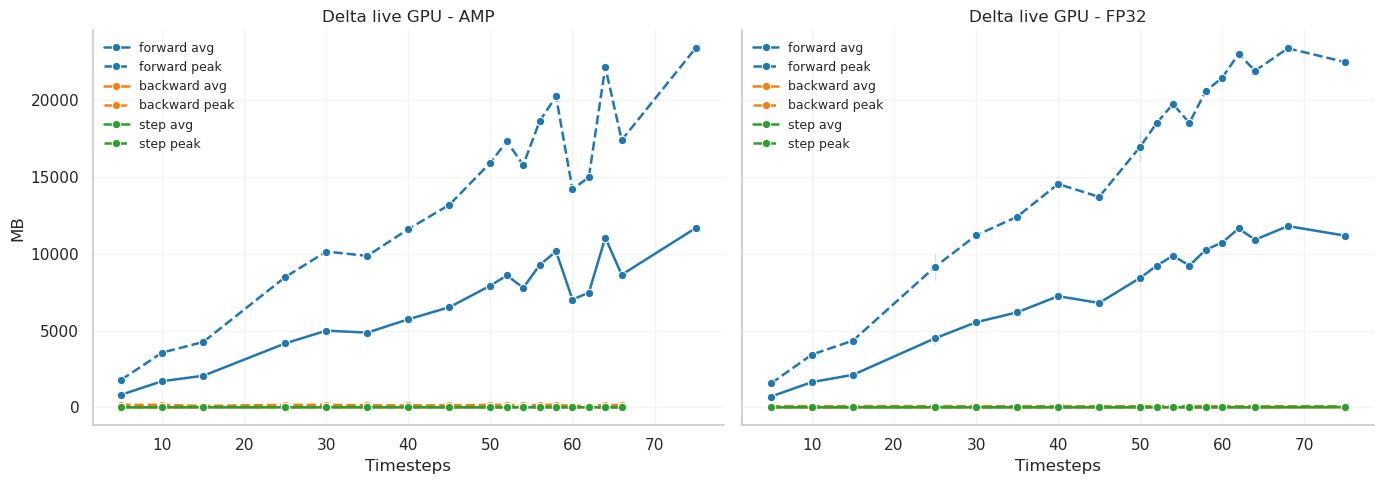

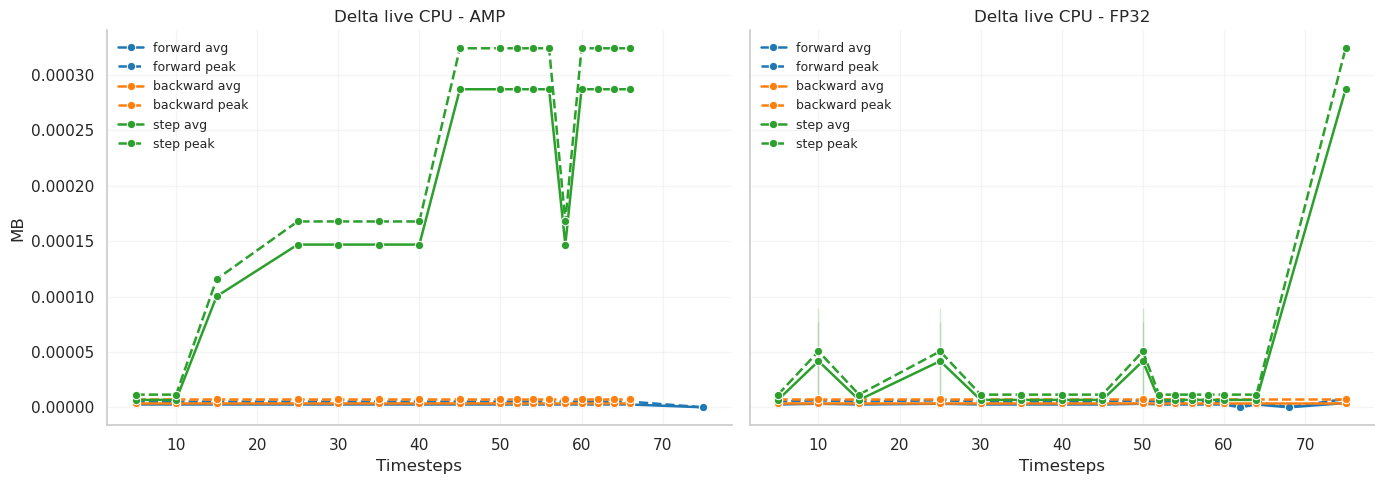

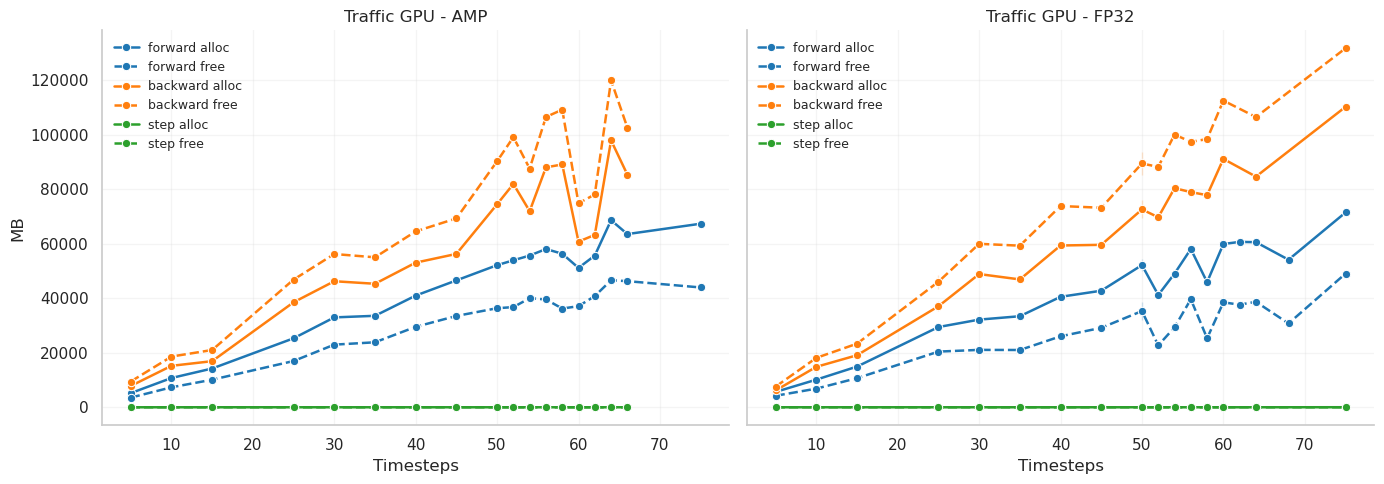

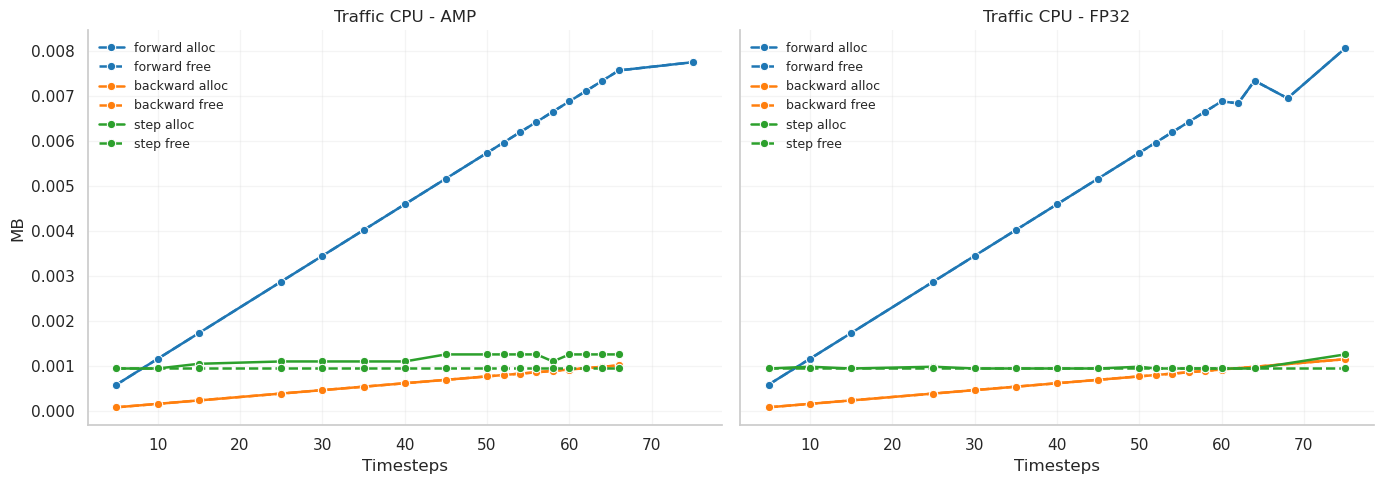


[Item 3]
- Si backward tiene delta bajo pero traffic alto, hay reutilización/caching con actividad real de allocator.
- Comparar AMP vs FP32 por fase ayuda a identificar dónde crece más la memoria.


In [6]:
phase_defs = [("train_forward", "forward"), ("train_backward", "backward"), ("train_step", "step")]


def plot_delta(device_tag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
    for ax, amp in zip(axes, [True, False]):
        sub = df[df["use_amp"] == amp].sort_values("timesteps")
        for phase_key, phase_label in phase_defs:
            avg_col = f"{phase_key}_alloc_delta_avg_mb_{device_tag}"
            peak_col = f"{phase_key}_alloc_delta_peak_mb_{device_tag}"
            color = PHASE_COLORS[phase_key]
            if avg_col in sub and sub[avg_col].notna().any():
                sns.lineplot(data=sub, x="timesteps", y=avg_col, marker="o", linewidth=1.8, linestyle="-", color=color, label=f"{phase_label} avg", ax=ax)
            if peak_col in sub and sub[peak_col].notna().any():
                sns.lineplot(data=sub, x="timesteps", y=peak_col, marker="o", linewidth=1.8, linestyle="--", color=color, label=f"{phase_label} peak", ax=ax)
        ax.set_title(f"Delta live {device_tag.upper()} - {AMP_LABELS[amp]}")
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("MB")
        h, _ = ax.get_legend_handles_labels()
        if h:
            ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_traffic(device_tag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
    for ax, amp in zip(axes, [True, False]):
        sub = df[df["use_amp"] == amp].sort_values("timesteps")
        for phase_key, phase_label in phase_defs:
            alloc_col = f"{phase_key}_alloc_traffic_mb_{device_tag}"
            free_col = f"{phase_key}_free_traffic_mb_{device_tag}"
            color = PHASE_COLORS[phase_key]
            if alloc_col in sub and sub[alloc_col].notna().any():
                sns.lineplot(data=sub, x="timesteps", y=alloc_col, marker="o", linewidth=1.8, linestyle="-", color=color, label=f"{phase_label} alloc", ax=ax)
            if free_col in sub and sub[free_col].notna().any():
                sns.lineplot(data=sub, x="timesteps", y=free_col, marker="o", linewidth=1.8, linestyle="--", color=color, label=f"{phase_label} free", ax=ax)
        ax.set_title(f"Traffic {device_tag.upper()} - {AMP_LABELS[amp]}")
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("MB")
        h, _ = ax.get_legend_handles_labels()
        if h:
            ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_delta("gpu")
plot_delta("cpu")
plot_traffic("gpu")
plot_traffic("cpu")

lines = [
    "Si backward tiene delta bajo pero traffic alto, hay reutilización/caching con actividad real de allocator.",
    "Comparar AMP vs FP32 por fase ayuda a identificar dónde crece más la memoria." 
]
mini_conclusion("Item 3", lines)

## Item 4: Fragmentación / presión de allocator
Se inspecciona `reserved - allocated` y su ratio para detectar posible fragmentación.

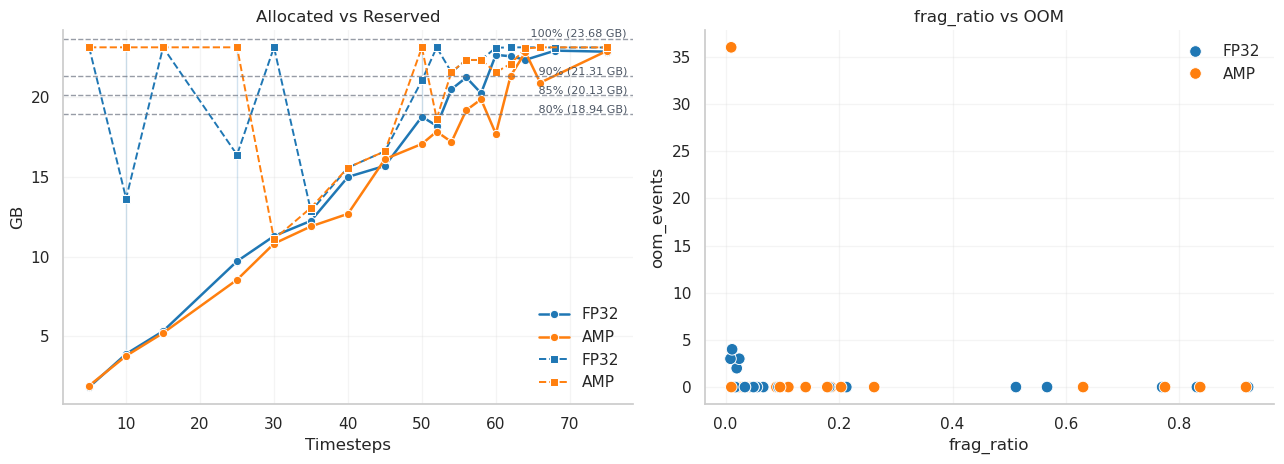


[Item 4]
- Corridas con frag_ratio > 0.20: 12/39
- Hay señales de presión de allocator; revisar tamaño/variabilidad de tensores y estrategia de batching.


In [7]:
frag_df = df.dropna(subset=["timesteps", "max_alloc_gb_trace", "max_reserved_gb_trace", "use_amp"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.lineplot(data=frag_df, x="timesteps", y="max_alloc_gb_trace", hue="use_amp", palette=PALETTE, marker="o", linewidth=1.8, ax=axes[0])
sns.lineplot(data=frag_df, x="timesteps", y="max_reserved_gb_trace", hue="use_amp", palette=PALETTE, marker="s", linewidth=1.4, linestyle="--", ax=axes[0])
add_a5000_guides(axes[0])
relabel_amp_legend(axes[0])
axes[0].set_title("Allocated vs Reserved")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("GB")

sns.scatterplot(data=frag_df, x="frag_ratio", y="oom_events", hue="use_amp", palette=PALETTE, s=70, ax=axes[1])
relabel_amp_legend(axes[1])
axes[1].set_title("frag_ratio vs OOM")
axes[1].set_xlabel("frag_ratio")
axes[1].set_ylabel("oom_events")
plt.tight_layout()
plt.show()

high_frag = frag_df[frag_df["frag_ratio"] > 0.20]
lines = [f"Corridas con frag_ratio > 0.20: {len(high_frag)}/{len(frag_df)}" if len(frag_df) else "Sin datos suficientes."]
if len(high_frag):
    lines.append("Hay señales de presión de allocator; revisar tamaño/variabilidad de tensores y estrategia de batching.")
else:
    lines.append("No se observan señales fuertes de fragmentación con el umbral actual.")
mini_conclusion("Item 4", lines)

## Item 5: Frontera OOM (`timesteps x batch_size`)

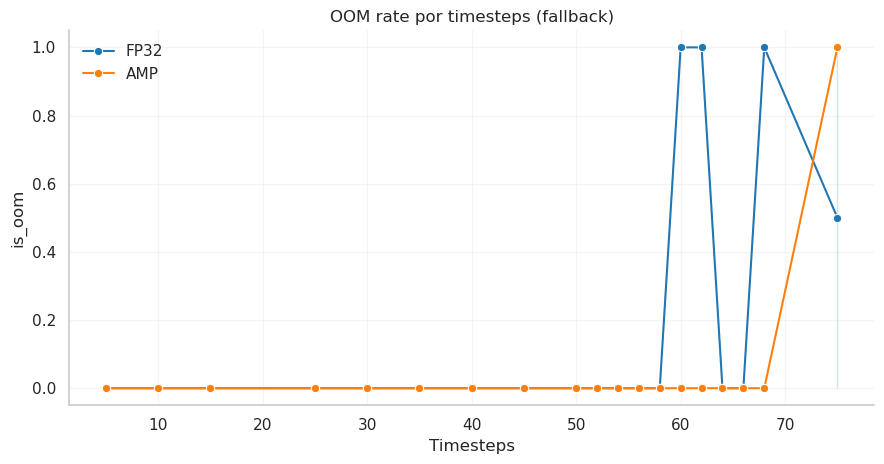


[Item 5]
- La frontera OOM define región operativa segura para escalar timesteps/batch.
- Corridas OOM: 5/42


In [8]:
state = np.where(df["is_oom"], "oom", np.where(df["is_ok"], "ok", "unknown"))
df["oom_state"] = state

pivot_ready = df.dropna(subset=["timesteps", "batch_size"]).copy()

if pivot_ready["timesteps"].nunique() > 1 and pivot_ready["batch_size"].nunique() > 1:
    map_state = {"ok": 0, "unknown": 1, "oom": 2}
    p = pivot_ready.assign(v=pivot_ready["oom_state"].map(map_state)).pivot_table(
        index="batch_size", columns="timesteps", values="v", aggfunc="max"
    )
    fig, ax = plt.subplots(figsize=(10, 4.8))
    sns.heatmap(p, cmap="RdYlGn_r", cbar=True, linewidths=0.3, ax=ax)
    ax.set_title("Frontera OOM (0=ok, 1=unknown, 2=oom)")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Batch size")
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(9, 4.8))
    tmp = pivot_ready.copy()
    tmp["oom_int"] = tmp["is_oom"].astype(int)
    sns.lineplot(data=tmp, x="timesteps", y="oom_int", hue="use_amp", palette=PALETTE, marker="o", ax=ax)
    relabel_amp_legend(ax)
    ax.set_title("OOM rate por timesteps (fallback)")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("is_oom")
    plt.tight_layout()
    plt.show()

lines = [
    "La frontera OOM define región operativa segura para escalar timesteps/batch.",
    f"Corridas OOM: {int(df['is_oom'].sum())}/{len(df)}",
]
mini_conclusion("Item 5", lines)

## Item 6: Contribución temporal `forward/backward/step`

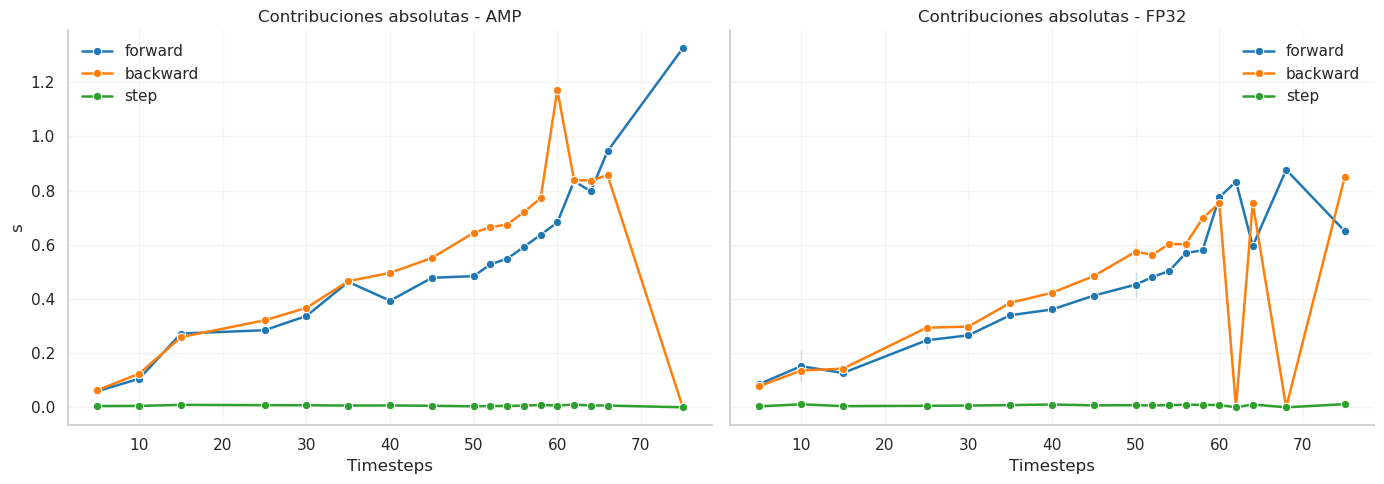

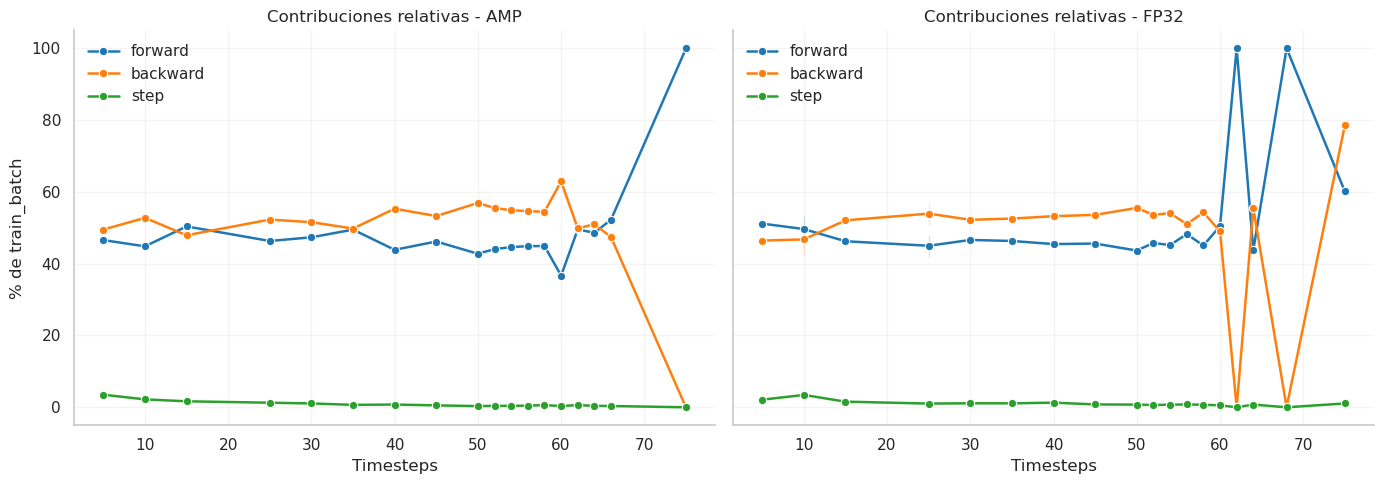


[Item 6]
- Fase dominante promedio: forward_pct
- Mirar cómo cambia al crecer timesteps para ubicar cuello de botella.


In [9]:
comp = df.dropna(subset=["timesteps", "train_batch_s", "use_amp"]).copy()
for col in ["train_forward_s", "train_backward_s", "train_step_s"]:
    if col not in comp:
        comp[col] = np.nan

for col, pct in [
    ("train_forward_s", "forward_pct"),
    ("train_backward_s", "backward_pct"),
    ("train_step_s", "step_pct"),
]:
    comp[pct] = 100.0 * comp[col] / comp["train_batch_s"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
for ax, amp in zip(axes, [True, False]):
    sub = comp[comp["use_amp"] == amp]
    for y, lbl, color in [
        ("train_forward_s", "forward", "#1f77b4"),
        ("train_backward_s", "backward", "#ff7f0e"),
        ("train_step_s", "step", "#2ca02c"),
    ]:
        if sub[y].notna().any():
            sns.lineplot(data=sub, x="timesteps", y=y, marker="o", linewidth=1.8, color=color, label=lbl, ax=ax)
    ax.set_title(f"Contribuciones absolutas - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("s")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
for ax, amp in zip(axes, [True, False]):
    sub = comp[comp["use_amp"] == amp]
    for y, lbl, color in [
        ("forward_pct", "forward", "#1f77b4"),
        ("backward_pct", "backward", "#ff7f0e"),
        ("step_pct", "step", "#2ca02c"),
    ]:
        if sub[y].notna().any():
            sns.lineplot(data=sub, x="timesteps", y=y, marker="o", linewidth=1.8, color=color, label=lbl, ax=ax)
    ax.set_title(f"Contribuciones relativas - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("% de train_batch")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

phase_means = comp[["forward_pct", "backward_pct", "step_pct"]].mean(numeric_only=True)
dominant = phase_means.idxmax() if len(phase_means.dropna()) else "n/a"
mini_conclusion("Item 6", [f"Fase dominante promedio: {dominant}", "Mirar cómo cambia al crecer timesteps para ubicar cuello de botella."])

## Item 7: CPU vs GPU

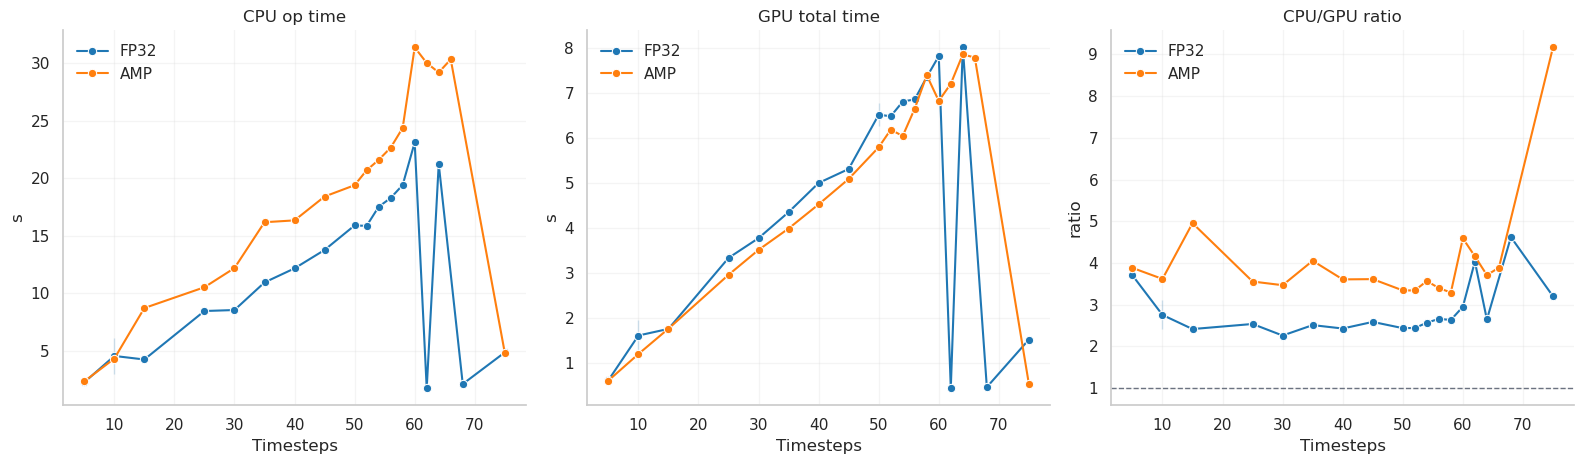


[Item 7]
- AMP: ratio mediano=3.62 -> domina CPU
- FP32: ratio mediano=2.59 -> domina CPU


In [10]:
cg = df.dropna(subset=["timesteps", "cpu_op_s_trace", "gpu_total_s_trace", "use_amp"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
sns.lineplot(data=cg, x="timesteps", y="cpu_op_s_trace", hue="use_amp", palette=PALETTE, marker="o", ax=axes[0])
relabel_amp_legend(axes[0])
axes[0].set_title("CPU op time")
axes[0].set_ylabel("s")

sns.lineplot(data=cg, x="timesteps", y="gpu_total_s_trace", hue="use_amp", palette=PALETTE, marker="o", ax=axes[1])
relabel_amp_legend(axes[1])
axes[1].set_title("GPU total time")
axes[1].set_ylabel("s")

sns.lineplot(data=cg, x="timesteps", y="cpu_gpu_ratio", hue="use_amp", palette=PALETTE, marker="o", ax=axes[2])
axes[2].axhline(1.0, color="#6b7280", linestyle="--", linewidth=1.0)
relabel_amp_legend(axes[2])
axes[2].set_title("CPU/GPU ratio")
axes[2].set_ylabel("ratio")

for ax in axes:
    ax.set_xlabel("Timesteps")

plt.tight_layout()
plt.show()

median_ratio = cg.groupby("use_amp")["cpu_gpu_ratio"].median()
lines = []
for amp in [True, False]:
    if amp in median_ratio.index and pd.notna(median_ratio.loc[amp]):
        dom = "CPU" if median_ratio.loc[amp] > 1.0 else "GPU"
        lines.append(f"{AMP_LABELS[amp]}: ratio mediano={median_ratio.loc[amp]:.2f} -> domina {dom}")
if not lines:
    lines = ["Sin datos suficientes para ratio CPU/GPU."]
mini_conclusion("Item 7", lines)

## Item 8: Estabilidad intra-run (aprox inter-run)
Se usa variabilidad entre corridas equivalentes (`timesteps`, `use_amp`).

,timesteps,use_amp,n_runs,train_mean_s,train_std_s,mem_mean_gb,mem_std_gb,train_cv,mem_cv
0,5,False,1,0.167672,NaN,1.821651,NaN,NaN,NaN
1,5,True,1,0.127686,NaN,1.906913,NaN,NaN,NaN
2,10,False,2,0.299222,0.135115,3.899246,0.015352,0.451555,0.003937
3,10,True,1,0.235426,NaN,3.776079,NaN,NaN,NaN
4,15,False,1,0.274095,NaN,5.329360,NaN,NaN,NaN
5,15,True,1,0.540934,NaN,5.210321,NaN,NaN,NaN
6,25,False,2,0.547287,0.054121,9.713032,0.438125,0.098890,0.045107
7,25,True,1,0.614622,NaN,8.552274,NaN,NaN,NaN
8,30,False,1,0.570765,NaN,11.292573,NaN,NaN,NaN
9,30,True,1,0.712638,NaN,10.819221,NaN,NaN,NaN


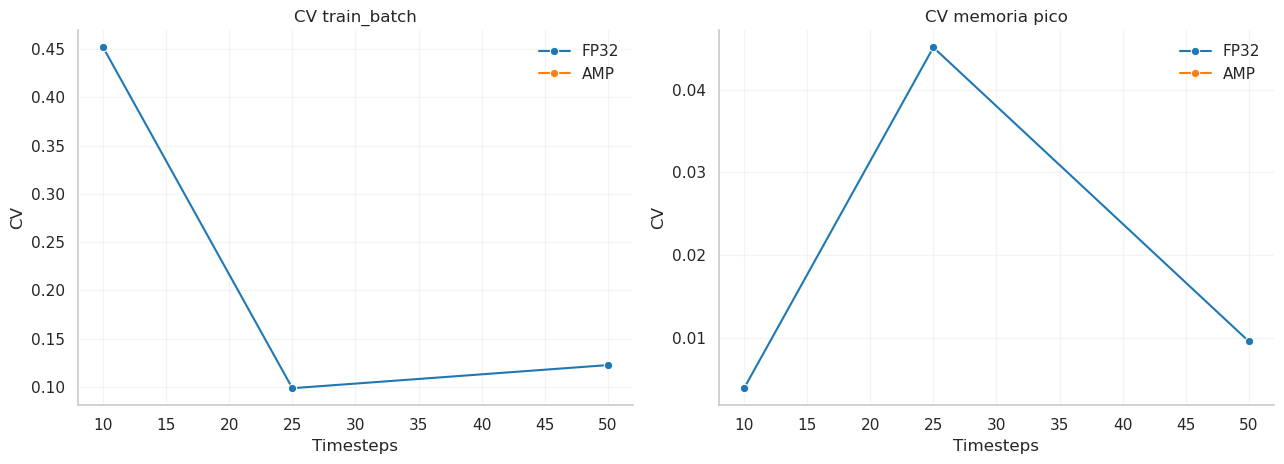


[Item 8]
- Grupos con CV alto (>0.15): 1/38
- CV alto sugiere inestabilidad o heterogeneidad de corridas.


In [11]:
stab = df.dropna(subset=["timesteps", "use_amp"]).copy()
agg = (
    stab.groupby(["timesteps", "use_amp"], dropna=False)
    .agg(
        n_runs=("run_name", "count"),
        train_mean_s=("train_batch_s", "mean"),
        train_std_s=("train_batch_s", "std"),
        mem_mean_gb=("max_alloc_gb_trace", "mean"),
        mem_std_gb=("max_alloc_gb_trace", "std"),
    )
    .reset_index()
)
agg["train_cv"] = agg["train_std_s"] / agg["train_mean_s"]
agg["mem_cv"] = agg["mem_std_gb"] / agg["mem_mean_gb"]
display(agg.sort_values(["timesteps", "use_amp"]).head(30))

if len(agg):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    sns.lineplot(data=agg, x="timesteps", y="train_cv", hue="use_amp", palette=PALETTE, marker="o", ax=axes[0])
    relabel_amp_legend(axes[0])
    axes[0].set_title("CV train_batch")
    axes[0].set_ylabel("CV")

    sns.lineplot(data=agg, x="timesteps", y="mem_cv", hue="use_amp", palette=PALETTE, marker="o", ax=axes[1])
    relabel_amp_legend(axes[1])
    axes[1].set_title("CV memoria pico")
    axes[1].set_ylabel("CV")

    for ax in axes:
        ax.set_xlabel("Timesteps")
    plt.tight_layout()
    plt.show()

hi = agg[(agg["train_cv"] > 0.15) | (agg["mem_cv"] > 0.15)]
mini_conclusion("Item 8", [f"Grupos con CV alto (>0.15): {len(hi)}/{len(agg)}", "CV alto sugiere inestabilidad o heterogeneidad de corridas."])

## Item 9: Eficiencia AMP real
Comparación directa AMP vs FP32 por `timesteps`.

,timesteps,max_alloc_gb_trace_fp32,max_alloc_gb_trace_amp,gain_pct_max_alloc_gb_trace,train_batch_s_fp32,train_batch_s_amp,gain_pct_train_batch_s,cpu_gpu_ratio_fp32,cpu_gpu_ratio_amp,gain_pct_cpu_gpu_ratio,train_forward_alloc_traffic_mb_gpu_fp32,train_forward_alloc_traffic_mb_gpu_amp,gain_pct_train_forward_alloc_traffic_mb_gpu,train_backward_alloc_traffic_mb_gpu_fp32,train_backward_alloc_traffic_mb_gpu_amp,gain_pct_train_backward_alloc_traffic_mb_gpu,train_step_alloc_traffic_mb_gpu_fp32,train_step_alloc_traffic_mb_gpu_amp,gain_pct_train_step_alloc_traffic_mb_gpu
0,5,1.821651,1.906913,-4.680468,0.167672,0.127686,23.847902,3.704887,3.883233,-4.813802,5650.099447,5201.910482,7.932408,6185.441081,7833.333822,-26.641475,11.049805,11.543132,-4.464575
1,10,3.899246,3.776079,3.158740,0.299222,0.235426,21.320846,2.755676,3.618380,-31.306454,10149.848206,10750.476562,-5.917609,14847.893148,15221.520996,-2.516369,13.897949,11.472168,17.454239
2,15,5.329360,5.210321,2.233646,0.274095,0.540934,-97.352621,2.417611,4.955612,-104.979718,14941.408691,14237.203288,4.713113,19108.436686,16927.540039,11.413266,10.862142,18.698568,-72.144388
3,25,9.713032,8.552274,11.950517,0.547287,0.614622,-12.303400,2.539212,3.556866,-40.077531,29452.719462,25317.562826,14.039982,37072.715454,38533.156413,-3.939396,13.604390,14.553385,-6.975652
4,30,11.292573,10.819221,4.191706,0.570765,0.712638,-24.856713,2.262070,3.468523,-53.333991,32175.523600,32989.484863,-2.529753,48888.023926,46258.089681,5.379506,10.698568,14.737956,-37.756344
5,35,12.250165,11.900572,2.853787,0.734158,0.935746,-27.458452,2.512323,4.054036,-61.366028,33421.294759,33573.417318,-0.455167,46920.857747,45330.666341,3.389093,10.637695,14.909831,-40.160348
6,40,15.002746,12.689190,15.420882,0.794873,0.897742,-12.941517,2.430437,3.607661,-48.436727,40547.024251,40993.687663,-1.101594,59370.654460,53083.179199,10.590207,10.640299,14.362956,-34.986386
7,45,15.698390,16.118614,-2.676865,0.904912,1.035836,-14.468147,2.589027,3.614015,-39.589691,42777.314128,46569.090983,-8.863990,59617.450358,56282.387533,5.594105,10.896159,10.848958,0.433185
8,50,18.781318,17.072995,9.095865,1.036246,1.132979,-9.334978,2.439484,3.343778,-37.069087,52183.077311,52154.769694,0.054247,72606.121460,74507.603678,-2.618901,13.955404,10.619141,23.906604
9,52,18.209216,17.846846,1.990039,1.051221,1.198991,-14.057023,2.443316,3.342800,-36.814029,41208.444010,53947.879883,-30.914625,69730.044922,81953.825358,-17.530149,10.640299,10.771647,-1.234436


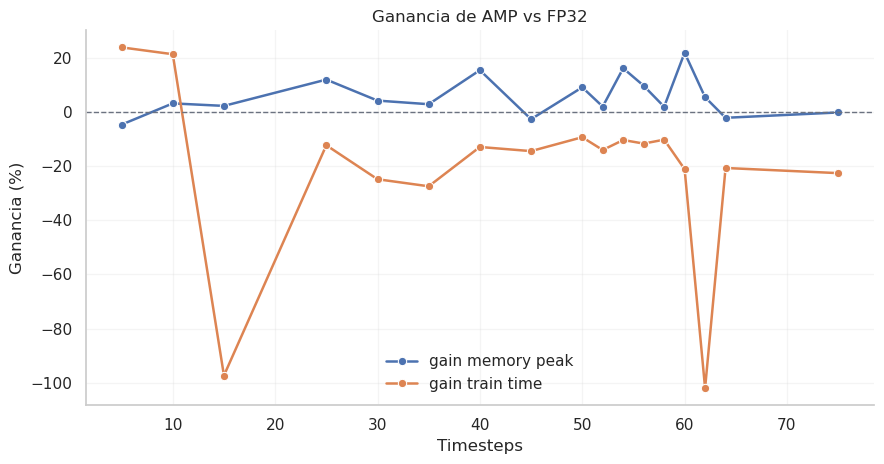


[Item 9]
- gain_pct_max_alloc_gb_trace: media=5.66%
- gain_pct_train_batch_s: media=-21.55%


In [12]:
pair_cols = [
    "max_alloc_gb_trace", "train_batch_s", "cpu_gpu_ratio",
    "train_forward_alloc_traffic_mb_gpu", "train_backward_alloc_traffic_mb_gpu", "train_step_alloc_traffic_mb_gpu",
]
pairs = df.dropna(subset=["timesteps", "use_amp"]).copy()

pt = pairs.pivot_table(index="timesteps", columns="use_amp", values=pair_cols, aggfunc="mean")

rows = []
for ts in pt.index:
    row = {"timesteps": ts}
    for metric in pair_cols:
        fp32 = pt.get((metric, False), pd.Series(index=pt.index)).get(ts, np.nan)
        amp = pt.get((metric, True), pd.Series(index=pt.index)).get(ts, np.nan)
        row[f"{metric}_fp32"] = fp32
        row[f"{metric}_amp"] = amp
        if pd.notna(fp32) and fp32 != 0 and pd.notna(amp):
            row[f"gain_pct_{metric}"] = 100.0 * (fp32 - amp) / fp32
        else:
            row[f"gain_pct_{metric}"] = np.nan
    rows.append(row)

amp_eff = pd.DataFrame(rows)
display(amp_eff.sort_values("timesteps"))

if len(amp_eff):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    if "gain_pct_max_alloc_gb_trace" in amp_eff:
        sns.lineplot(data=amp_eff, x="timesteps", y="gain_pct_max_alloc_gb_trace", marker="o", linewidth=1.8, label="gain memory peak", ax=ax)
    if "gain_pct_train_batch_s" in amp_eff:
        sns.lineplot(data=amp_eff, x="timesteps", y="gain_pct_train_batch_s", marker="o", linewidth=1.8, label="gain train time", ax=ax)
    ax.axhline(0.0, color="#6b7280", linestyle="--", linewidth=1.0)
    ax.set_title("Ganancia de AMP vs FP32")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Ganancia (%)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

lines = []
for m in ["gain_pct_max_alloc_gb_trace", "gain_pct_train_batch_s"]:
    if m in amp_eff and amp_eff[m].notna().any():
        lines.append(f"{m}: media={amp_eff[m].mean():.2f}%")
if not lines:
    lines = ["No hay pares AMP/FP32 suficientes para estimar ganancia."]
mini_conclusion("Item 9", lines)

## Item 10: Reporte ejecutivo por corrida
Semáforo usando `headroom` (A5000) + OOM + `frag_ratio`.

,run_name,status,timesteps,batch_size,use_amp,oom_events,max_alloc_gb_trace,headroom_gb,headroom_pct,frag_ratio,train_batch_s,risk_level,recommendation
37,sim90_bs4_pb4_68ts_fp32,oom,68,4,False,3.0,22.924428,0.755572,3.190762,0.008506,0.877585,red,bajar batch o timesteps; considerar gradient c...
41,sim90_bs4_pb4_75ts_amp,oom,75,4,True,36.0,22.904240,0.775760,3.276015,0.009714,1.326889,red,bajar batch o timesteps; considerar gradient c...
39,sim90_bs4_pb4_75ts,unknown,75,4,False,4.0,22.860162,0.819838,3.462153,0.011369,1.082300,red,bajar batch o timesteps; considerar gradient c...
34,sim90_bs4_pb4_64ts_amp,ok,64,4,True,0.0,22.831581,0.848419,3.582850,0.009929,1.642161,red,bajar batch o timesteps; considerar gradient c...
29,sim90_bs4_pb4_60ts_fp32,ok,60,4,False,2.0,22.658947,1.021053,4.311879,0.019491,1.537552,red,bajar batch o timesteps; considerar gradient c...
31,sim90_bs4_pb4_62ts_fp32,oom,62,4,False,3.0,22.571765,1.108235,4.680045,0.024006,0.834157,red,bajar batch o timesteps; considerar gradient c...
10,sim90_bs4_pb4_30ts_fp32,ok,30,4,False,0.0,11.292573,12.387427,52.311770,0.511837,0.570765,red,bajar batch o timesteps; considerar gradient c...
8,sim90_bs4_pb4_25ts_fp32,ok,25,4,False,0.0,10.022833,13.657167,57.673848,0.566727,0.585557,red,bajar batch o timesteps; considerar gradient c...
9,sim90_bs4_pb4_25ts_amp,ok,25,4,True,0.0,8.552274,15.127726,63.883977,0.630297,0.614622,red,bajar batch o timesteps; considerar gradient c...
5,sim90_bs4_pb4_15ts_fp32,ok,15,4,False,0.0,5.329360,18.350640,77.494255,0.769619,0.274095,red,bajar batch o timesteps; considerar gradient c...


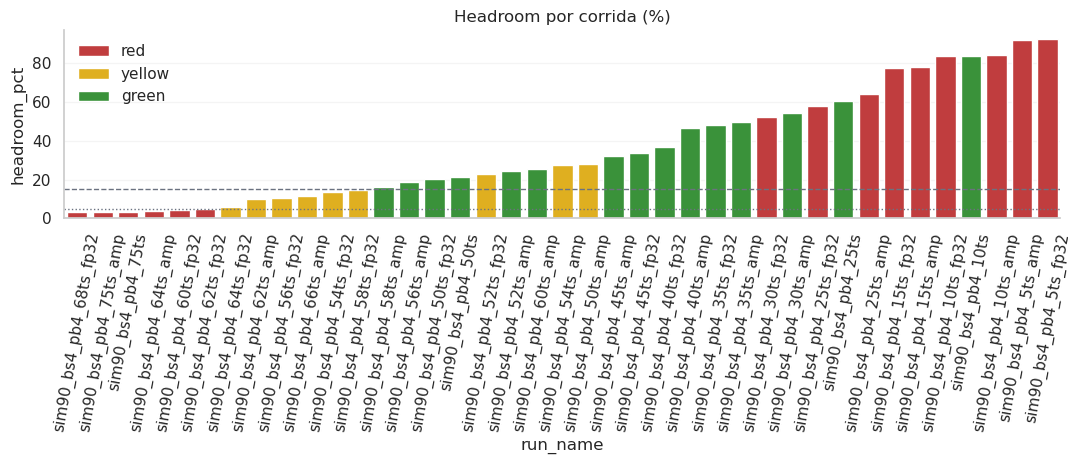


[Item 10]
- Riesgo red: 15
- Riesgo yellow: 9
- Riesgo green: 18


In [13]:
report = df.copy()


def risk_level(row):
    if bool(row.get("is_oom", False)):
        return "red"
    hp = row.get("headroom_pct", np.nan)
    fr = row.get("frag_ratio", np.nan)
    if pd.notna(hp) and hp < 5:
        return "red"
    if pd.notna(fr) and fr > 0.35:
        return "red"
    if pd.notna(hp) and hp < 15:
        return "yellow"
    if pd.notna(fr) and fr > 0.20:
        return "yellow"
    return "green"


def recommendation(row):
    lvl = row["risk_level"]
    if lvl == "red":
        return "bajar batch o timesteps; considerar gradient checkpoint"
    if lvl == "yellow":
        return "margen bajo; escalar con cuidado y monitorear frag_ratio"
    return "margen suficiente para escalar progresivamente"

report["risk_level"] = report.apply(risk_level, axis=1)
report["recommendation"] = report.apply(recommendation, axis=1)

order = pd.CategoricalDtype(["red", "yellow", "green"], ordered=True)
report["risk_level"] = report["risk_level"].astype(order)

cols = [
    "run_name", "status", "timesteps", "batch_size", "use_amp", "oom_events",
    "max_alloc_gb_trace", "headroom_gb", "headroom_pct", "frag_ratio",
    "train_batch_s", "risk_level", "recommendation",
]
for c in cols:
    if c not in report:
        report[c] = np.nan

scorecard = report[cols].sort_values(["risk_level", "headroom_pct", "timesteps"], ascending=[True, True, True])
display(scorecard)

fig, ax = plt.subplots(figsize=(11, 4.8))
plot_df = scorecard.dropna(subset=["headroom_pct"]).copy()
plot_df = plot_df.sort_values("headroom_pct")
if len(plot_df):
    sns.barplot(data=plot_df, x="run_name", y="headroom_pct", hue="risk_level", palette={"green": "#2ca02c", "yellow": "#ffbf00", "red": "#d62728"}, ax=ax)
    ax.axhline(15.0, color="#6b7280", linestyle="--", linewidth=1.0)
    ax.axhline(5.0, color="#6b7280", linestyle=":", linewidth=1.0)
    ax.set_title("Headroom por corrida (%)")
    ax.set_xlabel("run_name")
    ax.set_ylabel("headroom_pct")
    ax.tick_params(axis="x", rotation=80)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

risk_counts = scorecard["risk_level"].value_counts(dropna=False)
mini_conclusion("Item 10", [
    f"Riesgo red: {int(risk_counts.get('red', 0))}",
    f"Riesgo yellow: {int(risk_counts.get('yellow', 0))}",
    f"Riesgo green: {int(risk_counts.get('green', 0))}",
])

## Experimento Batch x GradAccum
Analisis especifico del sweep en `logs/diffusion_profiler_light_batch` con foco en plots simples.

- Primero: frontera de estado (`ok/unknown/oom`) por `timesteps x grad_accum_steps`, separado por modo y batch.
- Luego: curvas separadas para memoria y tiempo, una línea por `grad_accum_steps`.


In [14]:
from pathlib import Path
import sys

try:
    from profiler.profiler_tools import export_core_summary
except ModuleNotFoundError:
    candidates = [Path.cwd(), Path.cwd().parent]
    for cand in candidates:
        if (cand / "profiler" / "profiler_tools.py").exists() and str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
    from profiler.profiler_tools import export_core_summary

BATCH_LOG_ROOT = PROFILER_DIR / "logs" / "diffusion_profiler_light_batch"
BATCH_CORE_CSV = PROFILER_DIR / "profiler_runs_summary_core_batch.csv"
BATCH_FULL_CSV = PROFILER_DIR / "profiler_runs_summary_batch.csv"

if (not BATCH_CORE_CSV.exists()) and BATCH_LOG_ROOT.exists():
    _, _ = export_core_summary(
        log_root=BATCH_LOG_ROOT,
        output_csv=BATCH_CORE_CSV,
        output_full_csv=BATCH_FULL_CSV,
    )

if not BATCH_CORE_CSV.exists():
    raise FileNotFoundError(f"No existe {BATCH_CORE_CSV}. Corre profiler_summary.ipynb para este experimento.")

batch_df = pd.read_csv(BATCH_CORE_CSV)

for c in ["timesteps", "batch_size", "grad_accum_steps", "oom_events", "max_alloc_gb_trace", "train_batch_ms"]:
    if c not in batch_df.columns:
        batch_df[c] = np.nan
    batch_df[c] = pd.to_numeric(batch_df[c], errors="coerce")

if "use_amp" in batch_df.columns:
    batch_df["use_amp"] = normalize_use_amp(batch_df["use_amp"])
else:
    batch_df["use_amp"] = np.nan

if "status" not in batch_df.columns:
    batch_df["status"] = "unknown"
if "run_name" not in batch_df.columns:
    batch_df["run_name"] = [f"run_{i}" for i in range(len(batch_df))]

batch_df["grad_accum_steps"] = batch_df["grad_accum_steps"].fillna(1).clip(lower=1)
batch_df["train_batch_s"] = batch_df["train_batch_ms"] / 1000.0
batch_df["is_oom"] = batch_df["oom_events"].fillna(0) > 0
batch_df["effective_batch"] = batch_df["batch_size"] * batch_df["grad_accum_steps"]

mask = batch_df["run_name"].astype(str).str.contains("batch_ga_sweep", na=False)
batch_exp_df = batch_df[mask].copy() if mask.any() else batch_df.copy()

print(f"BATCH CSV: {BATCH_CORE_CSV}")
print(f"rows={len(batch_exp_df)} (subset sweep)")
display(batch_exp_df[["run_name","status","timesteps","batch_size","grad_accum_steps","effective_batch","use_amp","oom_events"]].head(20))


BATCH CSV: /home/gkulemeyer/Documents/Repos/RNADiffusion/profiler/profiler_runs_summary_core_batch.csv
rows=64 (subset sweep)


,run_name,status,timesteps,batch_size,grad_accum_steps,effective_batch,use_amp,oom_events
0,batch_ga_sweep_sim90_bs1_ga1_pb4_10ts_fp32,ok,10,1,1,1,False,0.0
1,batch_ga_sweep_sim90_bs1_ga2_pb4_10ts_fp32,ok,10,1,2,2,False,0.0
2,batch_ga_sweep_sim90_bs1_ga8_pb4_10ts_fp32,ok,10,1,8,8,False,0.0
3,batch_ga_sweep_sim90_bs4_ga1_pb4_10ts_fp32,ok,10,4,1,4,False,0.0
4,batch_ga_sweep_sim90_bs4_ga2_pb4_10ts_fp32,ok,10,4,2,8,False,0.0
5,batch_ga_sweep_sim90_bs4_ga8_pb4_10ts_fp32,ok,10,4,8,32,False,0.0
6,batch_ga_sweep_sim90_bs1_ga1_pb4_10ts_amp,ok,10,1,1,1,True,0.0
7,batch_ga_sweep_sim90_bs1_ga2_pb4_10ts_amp,ok,10,1,2,2,True,0.0
8,batch_ga_sweep_sim90_bs1_ga8_pb4_10ts_amp,ok,10,1,8,8,True,0.0
9,batch_ga_sweep_sim90_bs4_ga1_pb4_10ts_amp,ok,10,4,1,4,True,0.0


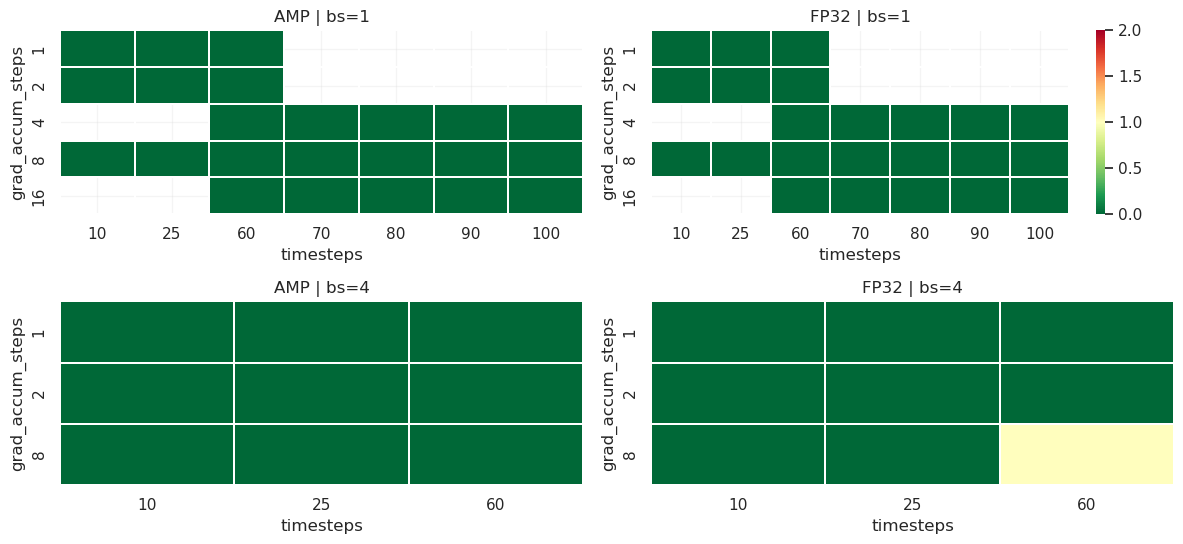


[Batch/GradAcc - frontera OOM]
- AMP bs=1: max timesteps estable = 100
- AMP bs=4: max timesteps estable = 60
- FP32 bs=1: max timesteps estable = 100
- FP32 bs=4: max timesteps estable = 60


In [15]:
# Matriz de estado: simple y separada por modo x batch
batch_view = batch_exp_df.copy()
batch_view["oom_state"] = np.where(
    batch_view["is_oom"],
    "oom",
    np.where(batch_view["status"].astype(str).str.lower().eq("ok"), "ok", "unknown"),
)
state_map = {"ok": 0, "unknown": 1, "oom": 2}
batch_view["state_code"] = batch_view["oom_state"].map(state_map)

bs_vals = sorted(batch_view["batch_size"].dropna().astype(int).unique().tolist())
amp_vals = [True, False]

if len(bs_vals) == 0:
    mini_conclusion("Batch/GradAcc - estado", ["No hay datos de batch_size para analizar."])
else:
    fig, axes = plt.subplots(len(bs_vals), len(amp_vals), figsize=(12, max(3.0, 2.8 * len(bs_vals))), squeeze=False)

    for i, bs in enumerate(bs_vals):
        for j, amp in enumerate(amp_vals):
            ax = axes[i][j]
            sub = batch_view[(batch_view["batch_size"] == bs) & (batch_view["use_amp"] == amp)].copy()
            if len(sub) == 0:
                ax.set_axis_off()
                continue

            pv = sub.pivot_table(
                index="grad_accum_steps",
                columns="timesteps",
                values="state_code",
                aggfunc="max",
            ).sort_index()

            sns.heatmap(
                pv,
                cmap="RdYlGn_r",
                vmin=0,
                vmax=2,
                linewidths=0.3,
                cbar=(i == 0 and j == len(amp_vals) - 1),
                ax=ax,
            )
            ax.set_title(f"{AMP_LABELS[amp]} | bs={bs}")
            ax.set_xlabel("timesteps")
            ax.set_ylabel("grad_accum_steps")

    plt.tight_layout()
    plt.show()

lines = []
for amp in amp_vals:
    for bs in bs_vals:
        sub = batch_view[
            (batch_view["use_amp"] == amp)
            & (batch_view["batch_size"] == bs)
            & (batch_view["oom_state"] == "ok")
        ]
        if len(sub):
            lines.append(f"{AMP_LABELS[amp]} bs={bs}: max timesteps estable = {int(sub['timesteps'].max())}")

mini_conclusion("Batch/GradAcc - frontera OOM", lines if lines else ["No hay corridas estables para estimar frontera."])


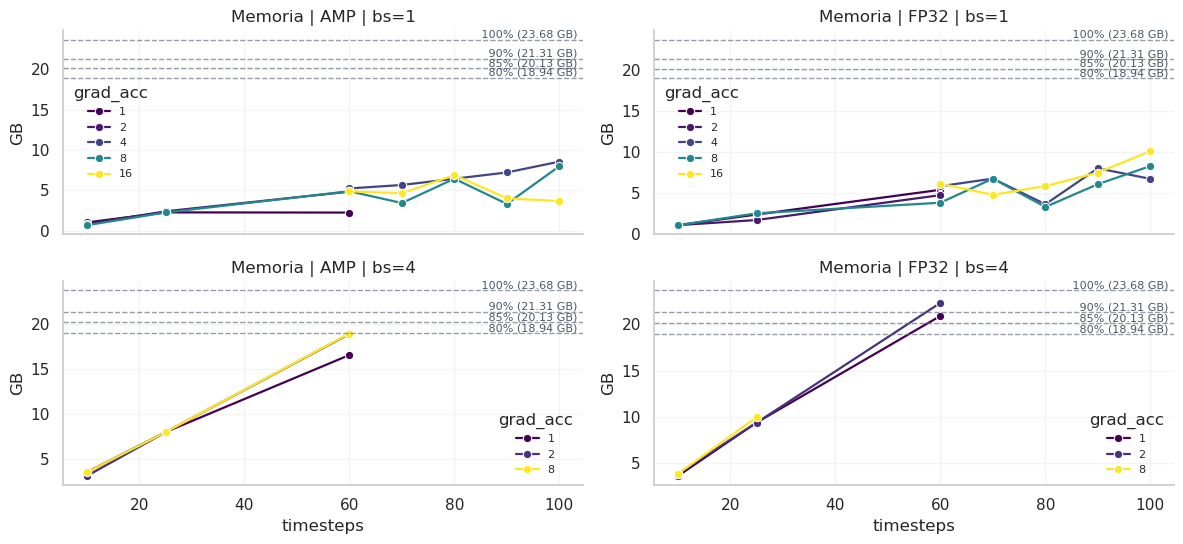

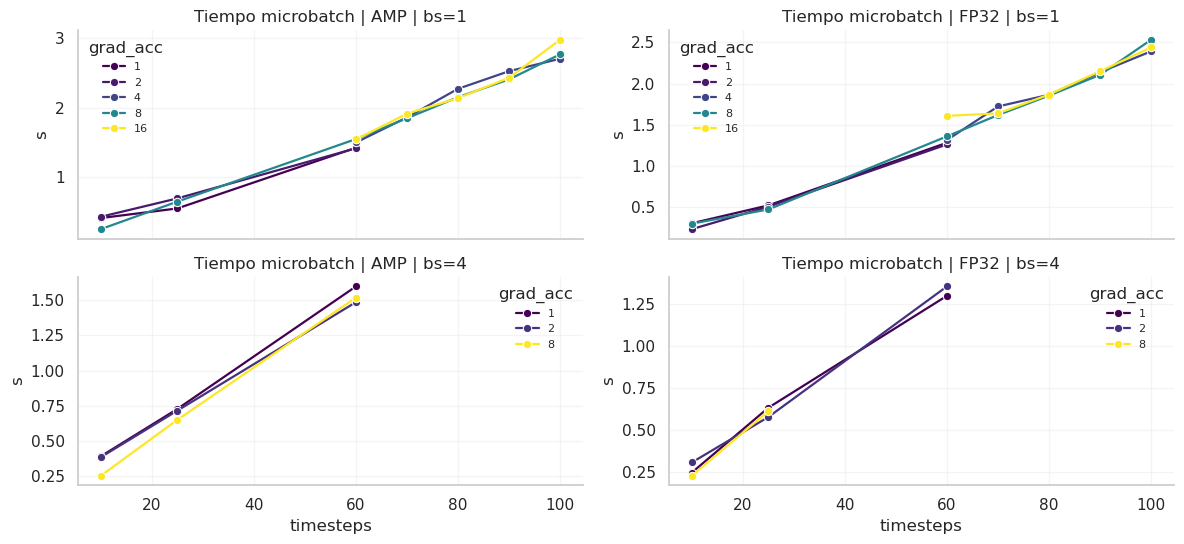

,timesteps,use_amp,batch_size,grad_accum_steps,effective_batch,train_batch_s,max_alloc_gb_trace,headroom_gb
0,10,False,4,8,32,0.226641,3.871814,19.808186
1,10,True,4,8,32,0.253134,3.529344,20.150656
2,25,False,4,8,32,0.612483,9.991802,13.688198
3,25,True,4,8,32,0.650684,7.980199,15.699801
4,60,False,1,16,16,1.608418,6.109590,17.570410
5,60,True,4,8,32,1.519069,18.900131,4.779869
6,70,False,1,16,16,1.637767,4.748586,18.931414
7,70,True,1,16,16,1.910920,4.626208,19.053792
8,80,False,1,16,16,1.866292,5.808769,17.871231
9,80,True,1,16,16,2.135809,6.894478,16.785522



[Batch/GradAcc - resumen]
- Gráficos separados por modo y batch para lectura directa.
- Cada línea representa un grad_accum_steps.
- Usa la tabla final para elegir configuración por timesteps con margen de memoria.


In [16]:
# Curvas simples por modo x batch (una linea por grad_accum_steps)
ok_sub = batch_exp_df[
    (~batch_exp_df["is_oom"]) & (batch_exp_df["status"].astype(str).str.lower() == "ok")
].copy()

if len(ok_sub) == 0:
    mini_conclusion("Batch/GradAcc - curvas", ["No hay corridas estables para graficar."])
else:
    ok_sub["batch_size"] = ok_sub["batch_size"].astype(int)
    ok_sub["grad_accum_steps"] = ok_sub["grad_accum_steps"].astype(int)

    bs_vals = sorted(ok_sub["batch_size"].dropna().unique().tolist())
    amp_vals = [True, False]

    # A) Memoria vs timesteps
    fig, axes = plt.subplots(len(bs_vals), len(amp_vals), figsize=(12, max(3.0, 2.8 * len(bs_vals))), squeeze=False, sharex=True)
    for i, bs in enumerate(bs_vals):
        for j, amp in enumerate(amp_vals):
            ax = axes[i][j]
            sub = ok_sub[(ok_sub["batch_size"] == bs) & (ok_sub["use_amp"] == amp)].sort_values(["grad_accum_steps", "timesteps"])
            if len(sub) == 0:
                ax.set_axis_off()
                continue
            sns.lineplot(
                data=sub,
                x="timesteps",
                y="max_alloc_gb_trace",
                hue="grad_accum_steps",
                marker="o",
                linewidth=1.6,
                palette="viridis",
                ax=ax,
            )
            add_a5000_guides(ax)
            ax.set_title(f"Memoria | {AMP_LABELS[amp]} | bs={bs}")
            ax.set_xlabel("timesteps")
            ax.set_ylabel("GB")
            ax.legend(title="grad_acc", loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

    # B) Tiempo por microbatch vs timesteps
    fig, axes = plt.subplots(len(bs_vals), len(amp_vals), figsize=(12, max(3.0, 2.8 * len(bs_vals))), squeeze=False, sharex=True)
    for i, bs in enumerate(bs_vals):
        for j, amp in enumerate(amp_vals):
            ax = axes[i][j]
            sub = ok_sub[(ok_sub["batch_size"] == bs) & (ok_sub["use_amp"] == amp)].sort_values(["grad_accum_steps", "timesteps"])
            if len(sub) == 0:
                ax.set_axis_off()
                continue
            sns.lineplot(
                data=sub,
                x="timesteps",
                y="train_batch_s",
                hue="grad_accum_steps",
                marker="o",
                linewidth=1.6,
                palette="viridis",
                ax=ax,
            )
            ax.set_title(f"Tiempo microbatch | {AMP_LABELS[amp]} | bs={bs}")
            ax.set_xlabel("timesteps")
            ax.set_ylabel("s")
            ax.legend(title="grad_acc", loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

    # Tabla compacta para elegir config por (timesteps, modo)
    ok_sub["effective_batch"] = ok_sub["batch_size"] * ok_sub["grad_accum_steps"]
    ok_sub["headroom_gb"] = A5000_GB - ok_sub["max_alloc_gb_trace"]

    best = (
        ok_sub.sort_values(["timesteps", "use_amp", "effective_batch", "train_batch_s"], ascending=[True, True, False, True])
        .groupby(["timesteps", "use_amp"], as_index=False)
        .first()
    )
    display(best[["timesteps", "use_amp", "batch_size", "grad_accum_steps", "effective_batch", "train_batch_s", "max_alloc_gb_trace", "headroom_gb"]])

    mini_conclusion(
        "Batch/GradAcc - resumen",
        [
            "Gráficos separados por modo y batch para lectura directa.",
            "Cada línea representa un grad_accum_steps.",
            "Usa la tabla final para elegir configuración por timesteps con margen de memoria.",
        ],
    )


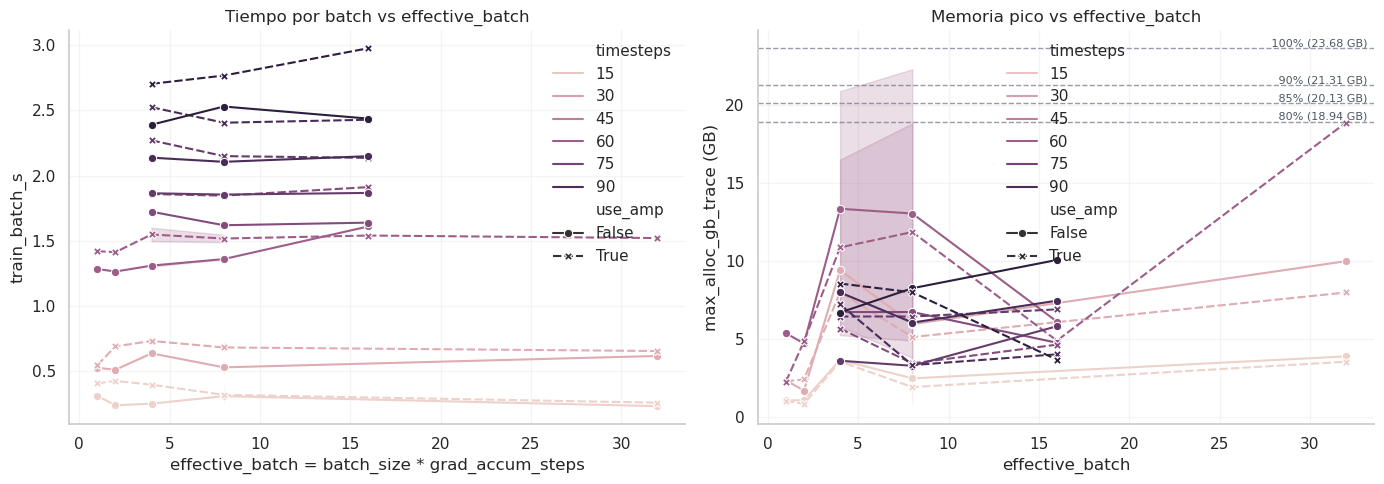

,timesteps,use_amp,batch_size,grad_accum_steps,effective_batch,train_batch_s,max_alloc_gb_trace,headroom_gb
0,10,False,1,1,1,0.304657,1.047190,22.632810
1,10,True,1,1,1,0.402212,1.017328,22.662672
2,25,False,1,1,1,0.521723,2.340869,21.339131
3,25,True,1,1,1,0.541390,2.266127,21.413873
4,60,False,1,1,1,1.281381,5.359625,18.320375
5,60,True,1,1,1,1.418271,2.240066,21.439934
6,70,False,1,4,4,1.721611,6.723317,16.956683
7,70,True,1,4,4,1.857276,5.659580,18.020420
8,80,False,1,4,4,1.863621,3.591810,20.088190
9,80,True,1,4,4,2.270425,6.435995,17.244005



[Batch/GradAcc - configuraciones recomendadas]
- Tabla muestra, por timesteps y modo, la config estable con mayor effective_batch (desempate por menor train_batch_s).
- Usar headroom_gb para elegir margen seguro antes de subir timesteps.


In [17]:
ok_sub = batch_exp_df[(~batch_exp_df["is_oom"]) & (batch_exp_df["status"].astype(str).str.lower() == "ok")].copy()

if len(ok_sub):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True)

    sns.lineplot(
        data=ok_sub,
        x="effective_batch",
        y="train_batch_s",
        hue="timesteps",
        style="use_amp",
        markers=True,
        dashes=True,
        ax=axes[0],
    )
    axes[0].set_title("Tiempo por batch vs effective_batch")
    axes[0].set_xlabel("effective_batch = batch_size * grad_accum_steps")
    axes[0].set_ylabel("train_batch_s")

    sns.lineplot(
        data=ok_sub,
        x="effective_batch",
        y="max_alloc_gb_trace",
        hue="timesteps",
        style="use_amp",
        markers=True,
        dashes=True,
        ax=axes[1],
    )
    add_a5000_guides(axes[1])
    axes[1].set_title("Memoria pico vs effective_batch")
    axes[1].set_xlabel("effective_batch")
    axes[1].set_ylabel("max_alloc_gb_trace (GB)")

    plt.tight_layout()
    plt.show()

    best = (
        ok_sub.sort_values(["effective_batch", "timesteps", "use_amp", "train_batch_s"], ascending=[True, True, False, True])
        .groupby(["timesteps", "use_amp"], as_index=False)
        .first()
    )

    best["headroom_gb"] = A5000_GB - best["max_alloc_gb_trace"]
    display(best[["timesteps","use_amp","batch_size","grad_accum_steps","effective_batch","train_batch_s","max_alloc_gb_trace","headroom_gb"]].sort_values(["timesteps","use_amp"]))

    mini_conclusion(
        "Batch/GradAcc - configuraciones recomendadas",
        [
            "Tabla muestra, por timesteps y modo, la config estable con mayor effective_batch (desempate por menor train_batch_s).",
            "Usar headroom_gb para elegir margen seguro antes de subir timesteps.",
        ],
    )
else:
    mini_conclusion("Batch/GradAcc - tradeoff", ["No hay corridas estables suficientes para comparar tradeoff."])


In [18]:
ok_sub[["timesteps","use_amp","batch_size","grad_accum_steps","effective_batch","train_batch_s","max_alloc_gb_trace",]].sort_values(["timesteps",])

,timesteps,use_amp,batch_size,grad_accum_steps,effective_batch,train_batch_s,max_alloc_gb_trace
0,10,False,1,1,1,0.304657,1.047190
1,10,False,1,2,2,0.233342,1.047268
2,10,False,1,8,8,0.300360,1.037873
3,10,False,4,1,4,0.245755,3.646644
4,10,False,4,2,8,0.306181,3.878447
...,...,...,...,...,...,...,...
59,100,False,1,4,4,2.390616,6.692035
60,100,False,1,8,8,2.530552,8.253953
61,100,True,1,16,16,2.978791,3.661392
62,100,True,1,4,4,2.704900,8.555220
